In [21]:

import open3d as o3d

# ----------------------------------------------------
# Replace with any point cloud you want to visualize
# ----------------------------------------------------
ply_path = r"D:\CVPR_Data\10Pig_PLY\Day1_2\497\Camera3\2025-11-01_01-22-22__2025-11-01_01-24-34\Camera3_1970-01-01_07-41-31_002248_depth.ply"
pcd = o3d.io.read_point_cloud(ply_path)

print(pcd)
print("Number of points:", len(pcd.points))

# ----------------------------------------------------
# Visualization
# ----------------------------------------------------
o3d.visualization.draw_geometries(
    [pcd],
    window_name="Segmented Point Cloud",
    width=1280,
    height=720,
    point_show_normal=False
)


PointCloud with 18795 points.
Number of points: 18795


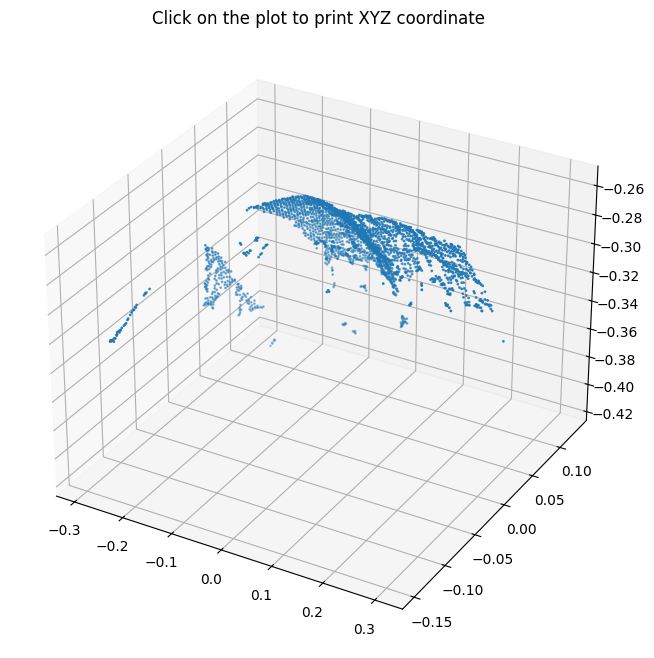

In [9]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d

# ==== Load point cloud ====
pc = o3d.io.read_point_cloud(
    r"D:\Cleaned_PC_O3D\Camera1_transfer_11_04_2025\1970-01-01\Camera1_1970-01-01_06-23-32_000396_depth.ply"
)
pts = np.asarray(pc.points)

# Downsample for speed (optional)
N = min(20000, len(pts))
idx = np.random.choice(len(pts), N, replace=False)
cloud = pts[idx]

# ==== Create figure ====
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(cloud[:,0], cloud[:,1], cloud[:,2], s=1)

ax.set_title("Click on the plot to print XYZ coordinate")


# ==== CLICK HANDLER ====
def onclick(event):
    if event.inaxes != ax:
        return

    # project all 3D points to 2D canvas coordinates
    x2, y2, _ = proj3d.proj_transform(cloud[:,0], cloud[:,1], cloud[:,2], ax.get_proj())
    xt, yt = ax.transData.transform(np.vstack([x2, y2]).T).T

    # click location
    dx = xt - event.x
    dy = yt - event.y
    dist = np.hypot(dx, dy)

    idx_min = np.argmin(dist)
    xyz = cloud[idx_min]

    print("Clicked XYZ:", xyz)

    # highlight clicked point
    ax.scatter([xyz[0]], [xyz[1]], [xyz[2]], c='red', s=40)
    plt.draw()


cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()
